# Network Comparison: `small` vs `small_parthenope`

This notebook compares the primordial abundances and time evolution predicted by the `small` network and the `small_parthenope` network.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the repo root is in path
sys.path.append(os.getcwd())

from pypr.main import PyPR

# Configuration
params = {
    "output_time_evolution": True,
    "verbose": False
}

# Solve for both networks
print("Solving small network...")
run_small = PyPR({**params, "network": "small"})
res_small = run_small.solve()

print("Solving small_parthenope network...")
run_parthenope = PyPR({**params, "network": "small_parthenope"})
res_parthenope = run_parthenope.solve()

print("Done.")

Solving small network...
[output] Time-evolution data (500 rows) written to /Users/pitrou/Cosmologie/SDrive/iap/PyPRIMAT/results/output_tables.tsv
Solving small_parthenope network...
[output] Time-evolution data (500 rows) written to /Users/pitrou/Cosmologie/SDrive/iap/PyPRIMAT/results/output_tables.tsv
Done.


In [2]:
# Compare final abundances
# Use abundance_names (the nuclide species list), not the solve() result keys
nuclides = [n for n in run_small.abundance_names
            if n in run_parthenope.abundance_names]
data = {
    "small": [run_small[n](run_small._t_vec[-1]) for n in nuclides],
    "small_parthenope": [run_parthenope[n](run_parthenope._t_vec[-1]) for n in nuclides],
}
df = pd.DataFrame(data, index=nuclides)
df["rel_diff"] = (df["small_parthenope"] - df["small"]) / df["small"]

print("Comparison of final abundances:")
print(df)

Comparison of final abundances:
            small  small_parthenope  rel_diff
n    4.029719e-16      4.154211e-16  0.030893
p    7.530269e-01      7.531407e-01  0.000151
H2   1.834783e-05      1.883837e-05  0.026736
H3   5.854121e-08      6.069813e-08  0.036844
He3  7.763680e-06      7.826881e-06  0.008141
He4  6.172825e-02      6.169949e-02 -0.000466
Li7  2.179082e-11      2.242940e-11  0.029305
Be7  3.959108e-10      3.865959e-10 -0.023528


/var/folders/x_/t8nzcr8d7_91h7fdrxdr8b180000gp/T/ipykernel_18925/451561553.py:23: RuntimeWarning: invalid value encountered in divide
  rel_diff = (Y_p_interp - Y_s) / Y_s


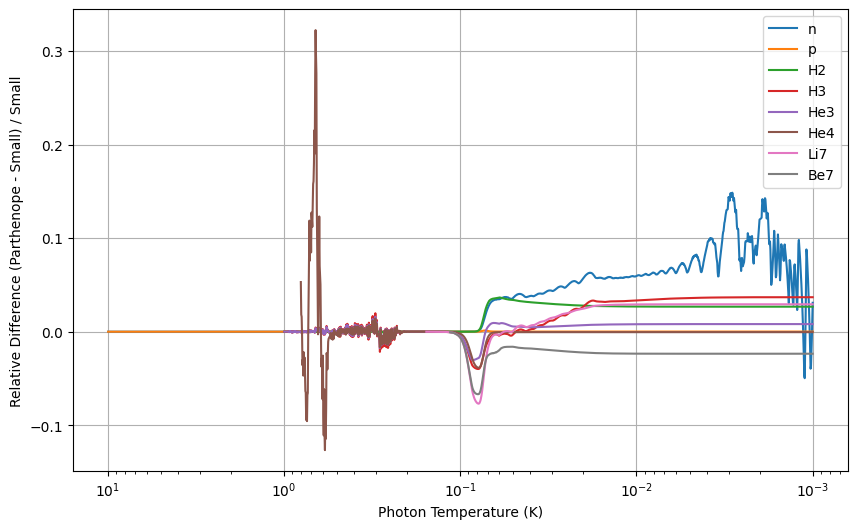

In [3]:
# Plot relative difference of nuclide time evolution
plt.figure(figsize=(10, 6))

# Access internal arrays for time and temperature
t_small = run_small._t_vec
t_parthenope = run_parthenope._t_vec
T_small = run_small._T_of_t(t_small)
T_parthenope = run_parthenope._T_of_t(t_parthenope)

for n in nuclides:
    if n in run_small.abundance_names and n in run_parthenope.abundance_names:
        # Get time-dependent abundance functions
        Y_small_fn = run_small[n]
        Y_parthenope_fn = run_parthenope[n]
        
        # Evaluate on the respective time grids
        Y_s = Y_small_fn(t_small)
        Y_p = Y_parthenope_fn(t_parthenope)
        
        # Interpolate parthenope evolution onto small grid
        # The temperature decreases with time.
        Y_p_interp = np.interp(T_small, T_parthenope[::-1], Y_p[::-1])
        rel_diff = (Y_p_interp - Y_s) / Y_s
        
        # Only plot for non-negligible abundances to avoid division issues
        mask = Y_s > 1e-25
        plt.plot(T_small[mask], rel_diff[mask], label=n)

plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Photon Temperature (K)")
plt.ylabel("Relative Difference (Parthenope - Small) / Small")
plt.legend()
plt.grid(True)
plt.show()